# Spider Dataset Exploration

Exploring the Spider text-to-SQL dataset before fine-tuning.

Goals:
- Understand dataset size and structure
- Look at SQL complexity distribution
- Identify what makes this task hard

In [1]:
import sys
sys.path.append('..')

from src.data.dataset_loader import SpiderDatasetLoader
from src.data.prompt_formatter import SQLPromptFormatter

loader = SpiderDatasetLoader()
train, eval = loader.load()

print(f"Train examples: {len(train)}")
print(f"Eval examples:  {len(eval)}")
print(f"\nExample:")
print(train[0])

c:\Users\Snapp\anaconda3\envs\sql-finetune\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-19 15:12:07 | INFO | src.data.dataset_loader | Initializing Spider dataset loader
2026-06-19 15:12:07 | INFO | src.data.dataset_loader | Loading Spider dataset from HuggingFace


2026-06-19 15:12:29 | INFO | src.data.dataset_loader | Dataset loaded
Train examples: 1000
Eval examples:  200

Example:
SQLExample(
  question='How many heads of the departments are older than 56 ?...'
  sql='SELECT count(*) FROM head WHERE age  >  56...'
  db='department_management'
  difficulty='unknown'
)


## Dataset Statistics

In [2]:
stats = loader.get_statistics(train)

print("Dataset statistics:")
for k, v in stats.items():
    print(f"  {k}: {v}")

Dataset statistics:
  total: 1000
  difficulties: {'unknown': 1000}
  avg_sql_length: 14.612
  avg_question_length: 12.208
  unique_databases: 19
  sql_keywords: {'SELECT': 1000, 'FROM': 1000, 'WHERE': 475, 'JOIN': 332, 'GROUP BY': 265, 'ORDER BY': 244, 'HAVING': 74, 'LIMIT': 181, 'UNION': 6, 'INTERSECT': 29}


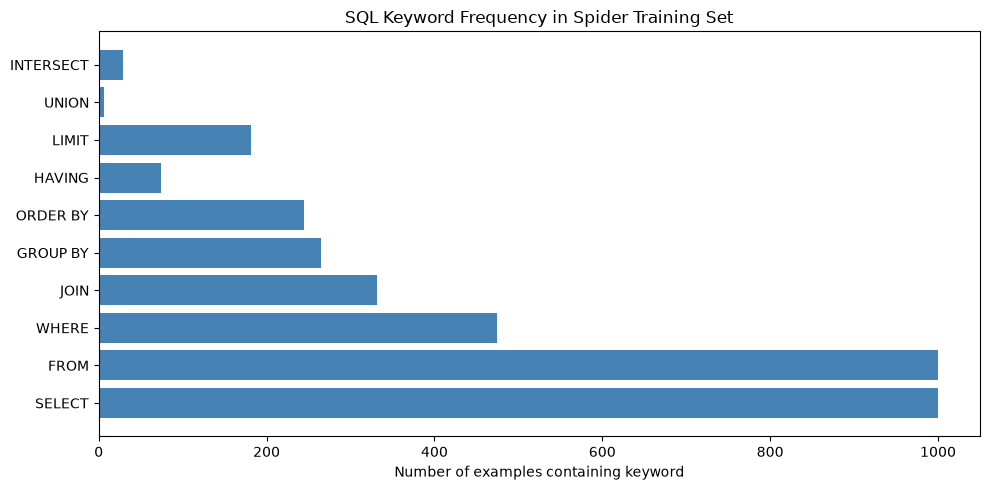


332 examples (33%) require JOINs
265 examples (26%) require GROUP BY
74 examples (7%) require HAVING — the hardest construct


In [3]:
import matplotlib.pyplot as plt

keywords = stats["sql_keywords"]

fig, ax = plt.subplots(figsize=(10, 5))
names  = list(keywords.keys())
counts = list(keywords.values())

ax.barh(names, counts, color='steelblue')
ax.set_xlabel("Number of examples containing keyword")
ax.set_title("SQL Keyword Frequency in Spider Training Set")
plt.tight_layout()
plt.savefig("../data/eval/sql_keyword_distribution.png", dpi=150)
plt.show()

print(f"\n{keywords['JOIN']} examples ({100*keywords['JOIN']/stats['total']:.0f}%) require JOINs")
print(f"{keywords['GROUP BY']} examples ({100*keywords['GROUP BY']/stats['total']:.0f}%) require GROUP BY")
print(f"{keywords['HAVING']} examples ({100*keywords['HAVING']/stats['total']:.0f}%) require HAVING — the hardest construct")

## Formatted Training Prompt Example

This is exactly what the model sees during training.

In [4]:
formatter = SQLPromptFormatter()

print("=== TRAINING PROMPT (includes answer) ===")
print(formatter.format_training(train[0]))
print("\n=== INFERENCE PROMPT (model must complete) ===")
print(formatter.format_inference(train[0]))

=== TRAINING PROMPT (includes answer) ===
### Task
Convert the following natural language question to a SQL query.

### Database Schema
Database: department_management

### Question
How many heads of the departments are older than 56 ?

### SQL
SELECT count(*) FROM head WHERE age  >  56

=== INFERENCE PROMPT (model must complete) ===
### Task
Convert the following natural language question to a SQL query.

### Database Schema
Database: department_management

### Question
How many heads of the departments are older than 56 ?

### SQL



## Key Takeaways

- 1000 training examples across 19 databases
- ~33% of queries require JOINs — genuinely hard for a small model
- ~7% require HAVING — the rarest, hardest SQL construct
- Average SQL length: ~15 tokens, average question length: ~12 tokens
- This is a small, focused subset of the full Spider dataset (7000 examples available)
  chosen to keep Colab training time under an hour